In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
#load data set

In [43]:
df=pd.read_csv('Housing.csv')

In [44]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [45]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [46]:
#Check info of all Data

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [48]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [49]:
df['price_lakhs']=df['price']/100000

In [50]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_lakhs
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,133.0000
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,122.5000
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,122.5000
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,122.1500
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,114.1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished,18.2000
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished,17.6715
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished,17.5000
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished,17.5000


In [56]:
bins=[0,25,50,75,100,df['price_lakhs'].max()]
labels=['0-25L','26-50L','51-75L','76-100L','>100L']

In [57]:
df['price_range']=pd.cut(df['price_lakhs'],bins=bins,labels=labels,include_lowest=True)

In [58]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_lakhs,price_range
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,133.0000,>100L
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,122.5000,>100L
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,122.5000,>100L
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,122.1500,>100L
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,114.1000,>100L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished,18.2000,0-25L
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished,17.6715,0-25L
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished,17.5000,0-25L
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished,17.5000,0-25L


In [59]:
price_counts=df['price_range'].value_counts().sort_index()

In [60]:
print(price_counts)

price_range
0-25L       32
26-50L     318
51-75L     148
76-100L     39
>100L        8
Name: count, dtype: int64


<module 'matplotlib.pyplot' from 'C:\\Users\\shine.DESKTOP-HU962IE\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

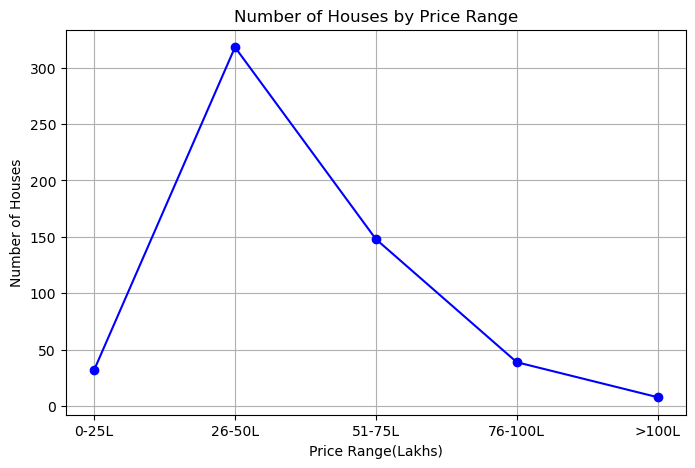

In [63]:
plt.figure(figsize=(8,5))
plt.plot(price_counts.index,price_counts.values,marker='o',color='blue')
plt.title('Number of Houses by Price Range')
plt.xlabel('Price Range(Lakhs)')
plt.ylabel('Number of Houses')
plt.grid(True)
plt

In [ ]:
##Step 3: Average Price For AC vs Non-AC Houses
'''Let's Calculate and compare the average prices for houses having air conditioning vs. those that do not.'''

In [ ]:
"Let's Calculate and compare the average prices for houses having air conditioning vs. those that do not.

In [65]:
avg_price_ac=df.groupby('airconditioning')['price_lakhs'].mean()

In [66]:
print(avg_price_ac)

airconditioning
no     41.919397
yes    60.132206
Name: price_lakhs, dtype: float64


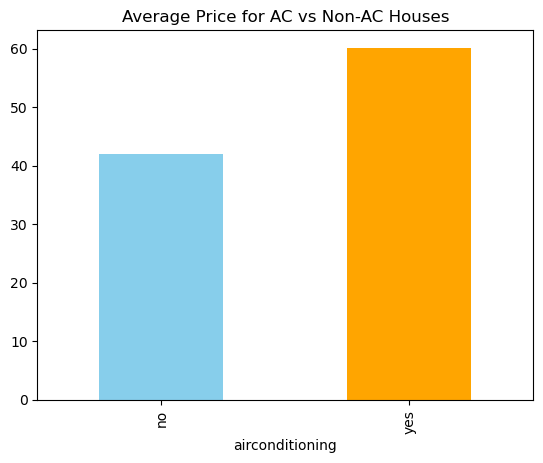

In [67]:
avg_price_ac.plot(kind='bar',color=['skyblue','orange'])
plt.title('Average Price for AC vs Non-AC Houses')
plt.xlabel=('Air Conditioning')
plt.ylabel=('Number of Houses')
plt.show()

In [ ]:
##Step 4:Relationship Between Parking and Parking
'''Let's see if houses with more parking spaces have higher prices.\n
We'll visualize this using a bar plot.

In [ ]:
"Let's see if houses with more parking spaces have higher prices.\nWe'll visualize this using a bar plot. \n"

C:\Users\shine.DESKTOP-HU962IE\AppData\Local\Temp\ipykernel_488\3882896330.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parking', y='price_lakhs',data=df,palette='coolwarm')


TypeError: 'str' object is not callable

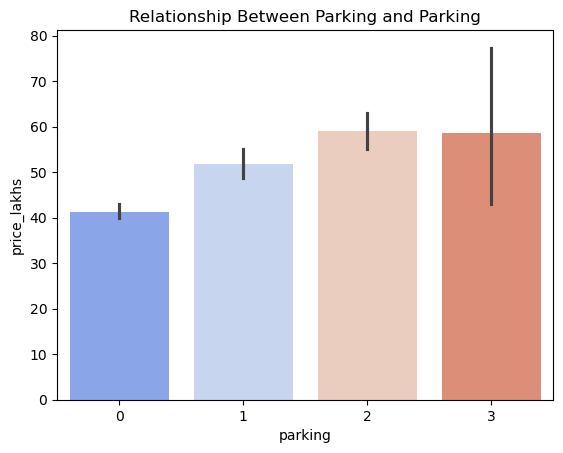

In [69]:
sns.barplot(x='parking', y='price_lakhs',data=df,palette='coolwarm')
plt.title('Relationship Between Parking and Parking')
plt.xlabel('Number of Parking Spots')
plt.ylabel("Average Price(Lakhs)")
plt.show()

In [71]:
group1=df[(df['area']<5000)&(df['prefarea']=='no')]['price_lakhs'].mean()
group2=df[(df['area']>5000)&(df['prefarea']=='yes')]['price_lakhs'].mean()

In [72]:
price_gap=group2-group1

In [73]:
print(f"Average price (<5000 sqft & no prefarea): {group1:.2f} lakhs")
print(f"Average price (>5000 sqft & prefarea): {group2:.2f} lakhs")
print(f"Price gap: {price_gap:.2f} lakhs")

Average price (<5000 sqft & no prefarea): 38.28 lakhs
Average price (>5000 sqft & prefarea): 65.47 lakhs
Price gap: 27.19 lakhs
